<a href="https://colab.research.google.com/github/ksjones21-bit/Budget-vs-Actual-analysis/blob/main/Apple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

df = pd.read_csv("/content/aapl_quarterly_master.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(182, 15)
['fiscal_year', 'fiscal_quarter', 'quarter_start', 'quarter_end', 'open_price', 'close_price', 'high_price', 'low_price', 'total_volume', 'avg_daily_return', 'return_volatility', 'quarter_return', 'avg_volatility', 'avg_rsi', 'price_return_pct']


,fiscal_year,fiscal_quarter,quarter_start,quarter_end,open_price,close_price,high_price,low_price,total_volume,avg_daily_return,return_volatility,quarter_return,avg_volatility,avg_rsi,price_return_pct
0,1981,Q1,1980-12-12,1980-12-31,0.098389,0.116784,0.123628,0.086412,1344851200,0.015527,0.049939,0.186321,NaN,NaN,0.186960
1,1981,Q2,1981-01-02,1981-03-31,0.118068,0.083845,0.118923,0.074006,1631324800,-0.004777,0.033508,-0.296170,0.006319,43.700581,-0.289856
2,1981,Q3,1981-04-01,1981-06-30,0.083417,0.088978,0.113790,0.082990,2077913600,0.001384,0.030000,0.087178,0.004790,55.890237,0.066663
3,1981,Q4,1981-07-01,1981-09-30,0.088550,0.052189,0.089834,0.048767,1959731200,-0.007630,0.036474,-0.488336,0.005890,32.904995,-0.410629
4,1982,Q1,1981-10-01,1981-12-31,0.052189,0.075717,0.078712,0.052189,2527974400,0.006340,0.032213,0.405733,0.003602,56.169470,0.450822


clean time axis

In [4]:
# Map quarters to numbers
quarter_map = {"Q1": 1, "Q2": 2, "Q3": 3, "Q4": 4}
df["quarter_num"] = df["fiscal_quarter"].map(quarter_map)

# Create period label
df["period"] = df["fiscal_year"].astype(str) + "-" + df["fiscal_quarter"]

# Sort properly
df = df.sort_values(["fiscal_year", "quarter_num"]).reset_index(drop=True)

df[["period", "close_price"]].head(10)

,period,close_price
0,1981-Q1,0.116784
1,1981-Q2,0.083845
2,1981-Q3,0.088978
3,1981-Q4,0.052189
4,1982-Q1,0.075717
5,1982-Q2,0.057751
6,1982-Q3,0.043634
7,1982-Q4,0.062456
8,1983-Q1,0.102240
9,1983-Q2,0.144590


Apple stock price over time

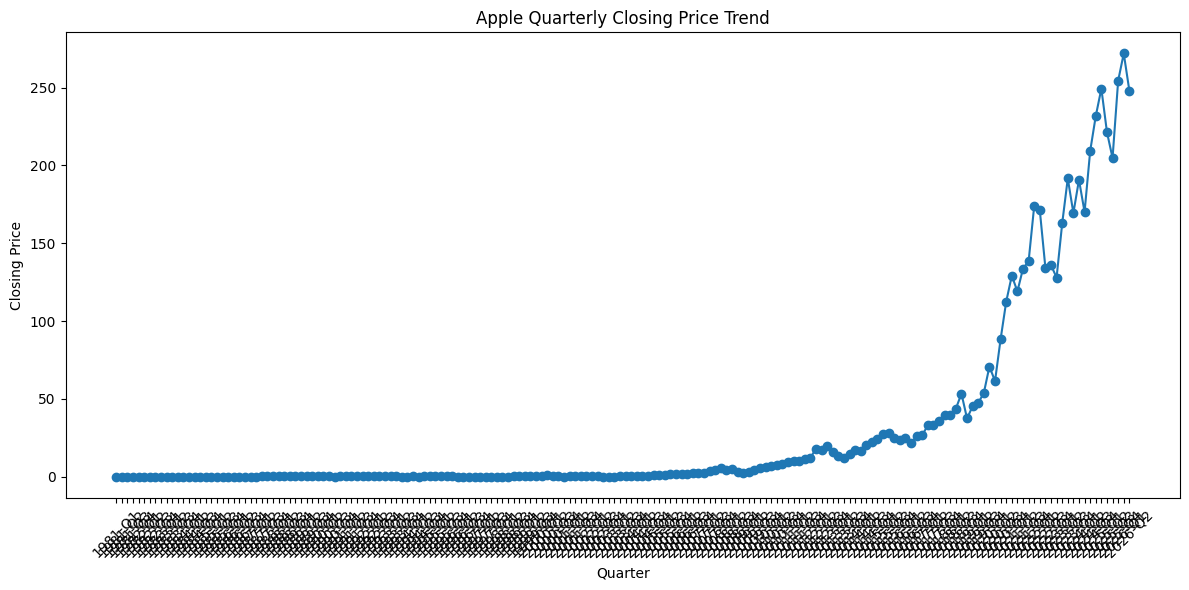

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df["period"], df["close_price"], marker="o")

plt.title("Apple Quarterly Closing Price Trend")
plt.xlabel("Quarter")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

growth (returns)

In [6]:
df["calc_return"] = df["close_price"].pct_change()

df[["period", "close_price", "quarter_return", "calc_return"]].tail(10)

,period,close_price,quarter_return,calc_return
172,2024-Q1,190.728775,0.121776,0.126007
173,2024-Q2,170.092468,-0.109118,-0.108197
174,2024-Q3,209.199112,0.216287,0.229914
175,2024-Q4,231.696030,0.109056,0.107538
176,2025-Q1,249.292526,0.077188,0.075946
177,2025-Q2,221.373016,-0.108792,-0.111995
178,2025-Q3,204.738937,-0.048232,-0.075140
179,2025-Q4,254.383408,0.225006,0.242477
180,2026-Q1,271.859985,0.070249,0.068702
181,2026-Q2,248.039993,-0.090663,-0.087619


average growth rate

In [7]:
avg_return = df["quarter_return"].mean()
median_return = df["quarter_return"].median()

print("Average Return:", avg_return)
print("Median Return:", median_return)

Average Return: 0.06728781898730869
Median Return: 0.10102722336442745


In [8]:
last_price = df["close_price"].iloc[-1]
last_price

np.float64(248.0399932861328)

Forecast next 4 quarters (base case)

In [9]:
n_forecast = 4

forecast_base = []
current_price = last_price

for i in range(n_forecast):
    current_price = current_price * (1 + avg_return)
    forecast_base.append(current_price)

forecast_base

[np.float64(264.7300634559834),
 np.float64(282.54317204630837),
 np.float64(301.5548858630604),
 np.float64(321.84585643775256)]

future quarter labels

In [10]:
last_year = df["fiscal_year"].iloc[-1]
last_quarter_num = df["quarter_num"].iloc[-1]

future_periods = []
future_years = []
future_quarters = []

for i in range(1, n_forecast + 1):
    next_q = last_quarter_num + i
    year = last_year + (next_q - 1) // 4
    quarter_num = ((next_q - 1) % 4) + 1
    quarter_label = f"Q{quarter_num}"

    future_years.append(year)
    future_quarters.append(quarter_label)
    future_periods.append(f"{year}-{quarter_label}")

future_periods

['2026-Q3', '2026-Q4', '2027-Q1', '2027-Q2']

forecast dataframe

In [11]:
forecast_df = pd.DataFrame({
    "period": future_periods,
    "forecast_base": forecast_base
})

forecast_df

,period,forecast_base
0,2026-Q3,264.730063
1,2026-Q4,282.543172
2,2027-Q1,301.554886
3,2027-Q2,321.845856


scenarios

In [12]:
bull_return = avg_return + 0.05
bear_return = avg_return - 0.05

bull_values = []
bear_values = []

current_bull = last_price
current_bear = last_price

for i in range(n_forecast):
    current_bull = current_bull * (1 + bull_return)
    current_bear = current_bear * (1 + bear_return)

    bull_values.append(current_bull)
    bear_values.append(current_bear)

forecast_df["forecast_bull"] = bull_values
forecast_df["forecast_bear"] = bear_values

forecast_df

,period,forecast_base,forecast_bull,forecast_bear
0,2026-Q3,264.730063,277.132063,252.328064
1,2026-Q4,282.543172,309.636278,256.690266
2,2027-Q1,301.554886,345.952842,261.127881
3,2027-Q2,321.845856,386.528896,265.642212


Plot

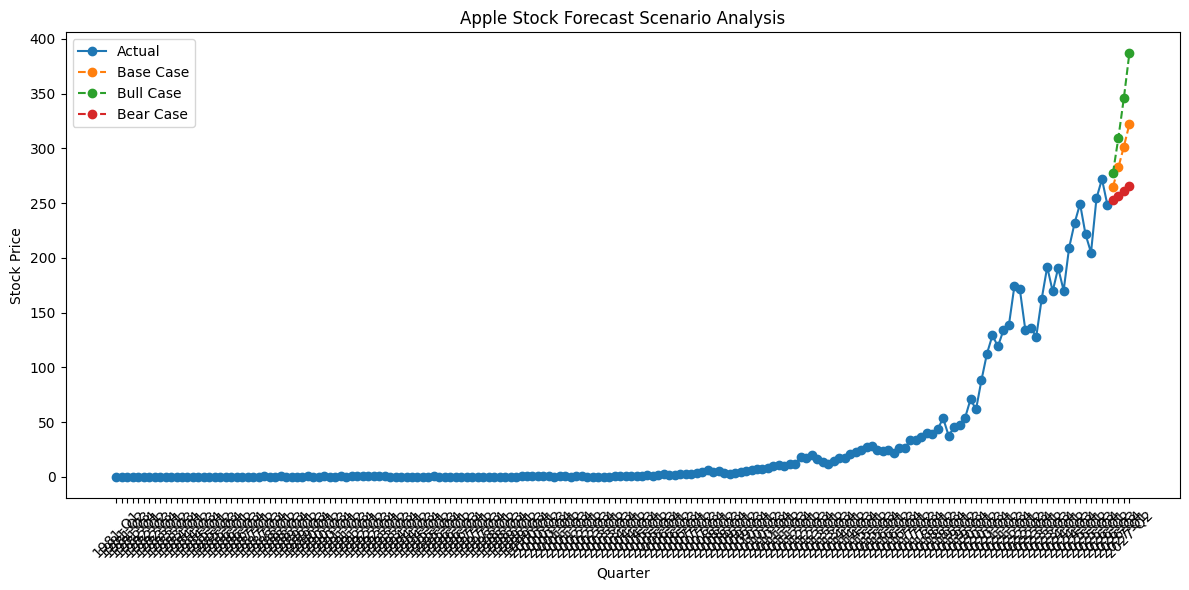

In [13]:
plt.figure(figsize=(12,6))

# Actual
plt.plot(df["period"], df["close_price"], label="Actual", marker="o")

# Forecasts
plt.plot(forecast_df["period"], forecast_df["forecast_base"], linestyle="--", marker="o", label="Base Case")
plt.plot(forecast_df["period"], forecast_df["forecast_bull"], linestyle="--", marker="o", label="Bull Case")
plt.plot(forecast_df["period"], forecast_df["forecast_bear"], linestyle="--", marker="o", label="Bear Case")

plt.title("Apple Stock Forecast Scenario Analysis")
plt.xlabel("Quarter")
plt.ylabel("Stock Price")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

Recent Performance

In [15]:
recent_df = df.tail(20)  # last 20 quarters (~5 years)

recent_avg_return = recent_df["quarter_return"].mean()

print("Recent Average Return:", recent_avg_return)

avg_return = recent_avg_return

Recent Average Return: 0.04571448167696136


Cap extreme growth

In [17]:
bull_return = min(avg_return + 0.05, 0.12)
bear_return = max(avg_return - 0.05, -0.10)

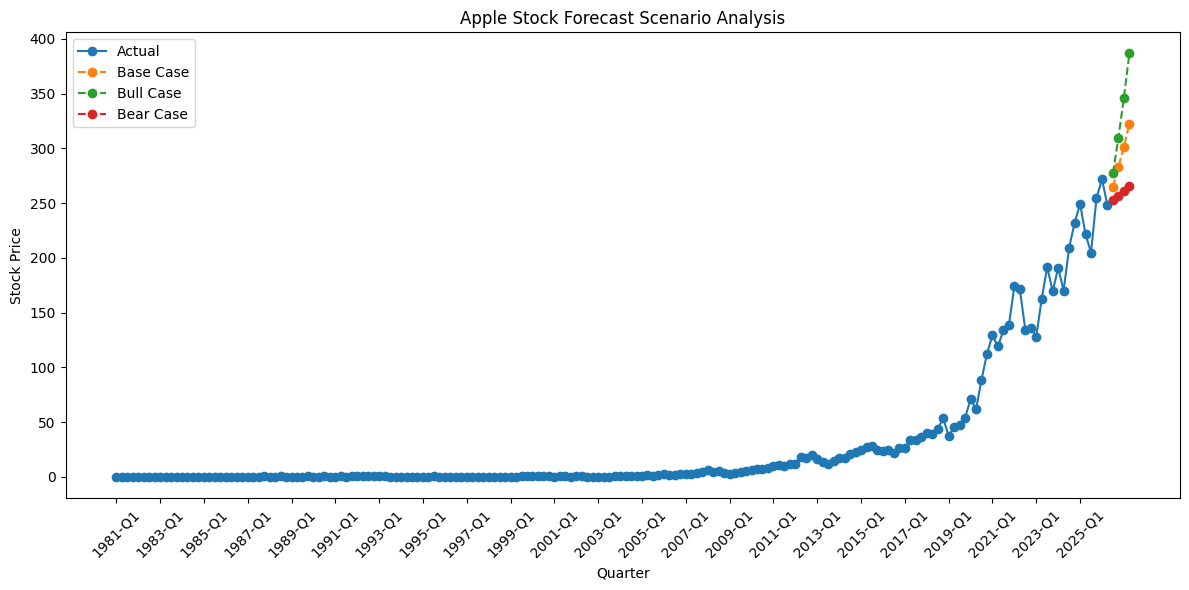

In [20]:
plt.figure(figsize=(12,6))

# Actual
plt.plot(df["period"], df["close_price"], label="Actual", marker="o")

# Forecasts
plt.plot(forecast_df["period"], forecast_df["forecast_base"], linestyle="--", marker="o", label="Base Case")
plt.plot(forecast_df["period"], forecast_df["forecast_bull"], linestyle="--", marker="o", label="Bull Case")
plt.plot(forecast_df["period"], forecast_df["forecast_bear"], linestyle="--", marker="o", label="Bear Case")

# Clean x-axis
tick_positions = range(0, len(df), 8)
tick_labels = df["period"].iloc[::8]
plt.xticks(ticks=tick_positions, labels=tick_labels, rotation=45)

plt.title("Apple Stock Forecast Scenario Analysis")
plt.xlabel("Quarter")
plt.ylabel("Stock Price")
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
plt.savefig("apple_forecast.png", bbox_inches='tight')

<Figure size 640x480 with 0 Axes>